In [1]:
import gpflow as gpf 
import numpy as np
import scipy.stats as ss
from scipy.spatial.distance import cdist
import tensorflow as tf 
from tslearn.metrics import dtw

import matplotlib.pyplot as plt 
import tqdm as tqdm
import os

import sys
sys.path.append("../..")

from atmodel import ConditionalMOGP, SparseCMOGP
from atlikelihood import TransferLikelihood

2026-05-28 09:06:20.331458: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-28 09:06:20.428225: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-28 09:06:20.610144: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-28 09:06:20.611597: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-28 09:06:21.903991: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

In [2]:
def optimize(m, plot_res=False):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50, "maxiter": 250})
    if plot_res:
        plt.plot(res["loss_history"])
        plt.show()

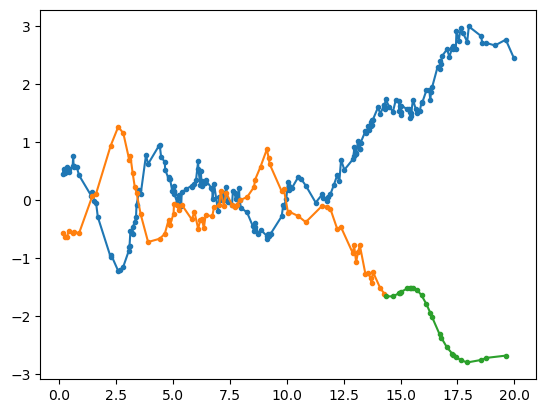

In [3]:
k = gpf.kernels.RBF(lengthscales=1, variance=1) #+ gpf.kernels.Linear(0.001)
Xall = np.sort(np.random.random(200) * 20)
Yall  = np.random.multivariate_normal(np.zeros_like(Xall), k(Xall.reshape(-1, 1)))
ind_1 = np.arange(0, 200, 1)
ind_2 = np.array([i for i in ind_1 if i % 2 == 0])
ind_1 = ind_1
ind_2 = ind_2
TEST_INDEX = int(0.75*len(ind_2))
ind_train, ind_test = ind_2[:TEST_INDEX], ind_2[TEST_INDEX:]
X1, y1 = Xall[ind_1], Yall[ind_1]
X2, y2 = Xall[ind_train], Yall[ind_train]
X2 = X2
y2 = -1*y2
Xtest, ytest = Xall[ind_test], Yall[ind_test]
ytest = -ytest
noise_variance = 0.1
y1 = y1.reshape(-1, 1) + np.random.normal(0, noise_variance, len(X1)).reshape(-1, 1)
y2 = y2.reshape(-1, 1) + np.random.normal(0, noise_variance, len(X2)).reshape(-1, 1) 
X1 = X1.reshape(-1, 1)
X2 = X2.reshape(-1, 1)
plt.plot(X1, y1, marker=".")
plt.plot(X2, y2, marker=".")
plt.plot(Xtest, ytest, marker=".")
X = np.vstack((np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2)))))
y = np.vstack((np.hstack((y1, np.zeros_like(y1))), np.hstack((y2, np.ones_like(y2)))))
plt.show()
X = tf.cast(X, np.float64)
y = tf.cast(y, np.float64)

In [4]:
exponents = np.arange(2, 11)
superlmls = []
output_dim = 2  # Number of outputs
rank = 1  # Rank of W
cross_cov = np.arange(-1, 1.25, 0.25)
for i in cross_cov:
    lmls = []
    for exponent in exponents:
        print(2 ** exponent)
        k = gpf.kernels.RBF(lengthscales=1)
        coreg = gpf.kernels.Coregion(
            output_dim=output_dim, rank=rank, active_dims=[1]
        )
        coreg.W = np.array([1., i]).reshape(-1, 1)
        kern = k * coreg
        m2 = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
        k = gpf.kernels.RBF(lengthscales=1)

        # Base kernel
        coreg = gpf.kernels.Coregion(
            output_dim=output_dim, rank=rank, active_dims=[1]
        )
        coreg.W = np.array([1., i]).reshape(-1, 1)

        # Coregion kernel
        ivs = np.linspace(0, max(X[:,0]), 2 ** exponent).reshape(-1, 1)
        iv_ind = np.concatenate((np.zeros((int(len(ivs)/2),1)), np.ones((int(len(ivs)/2),1))))
        shuffle = np.random.permutation(np.arange(len(ivs)))
        iv_ind = iv_ind[shuffle]
        ivs = np.hstack((ivs, iv_ind))
        kern = k * coreg

        minavg_distance_src = cdist(ivs[ivs[:,1] == 0], X[X[:,1] == 0]).min(axis=1).mean()
        minavg_distance_tgt = cdist(ivs[ivs[:,1] == 1], X[X[:,1] == 1]).min(axis=1).mean()

        m = SparseCMOGP((X, y), exact_target=False, kernel=kern, inducing_variable=ivs, jitter=1e-5, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
        quad, logdet, _ = m.conditional_likelihood(decompose_likelihood=True)
        lml_sparse = m.conditional_likelihood(decompose_likelihood=False)
        lml_dense = m2.maximum_log_likelihood_objective().numpy()
        lmls.append((lml_sparse.numpy(), quad[0], logdet.flatten()[0], lml_dense, minavg_distance_src, minavg_distance_tgt))
    print(lmls)
    superlmls.append(lmls)
superlmls = np.array(superlmls)


4
8
16
32
64
128
256
512
1024
[(-115.27620555323603, 65.47975709128507, 27.231876379612636, -84.30973190088764, 0.013240727835615917, 0.1335254094446645), (-105.59759647013148, 66.80531443331627, 6.5491008713723495, -84.30973190088764, 0.0730520720128931, 2.1720317868056593), (-99.80894419276954, 33.81244287720835, 27.964667872756404, -84.30973190088764, 0.051815351070966575, 0.6840900391420403), (-83.21074417621328, 23.168169649298854, 5.4125410675533665, -84.30973190088764, 0.06348595835226764, 1.1038307210728218), (-84.22148998756856, 27.78842649754536, 2.8137758420174053, -84.30973190088764, 0.05785745181035157, 0.847896906585274), (-84.25478184081791, 27.857251665205577, 2.8115343808559206, -84.30973190088764, 0.04346015278393473, 0.8076995730891863), (-84.25604241825232, 27.859804052197145, 2.8115031487331623, -84.30973190088764, 0.04841551911133128, 0.8309881289406904), (-84.25601875504377, 27.85975616521005, 2.8115037093031487, -84.30973190088764, 0.05471614916452512, 0.8699034

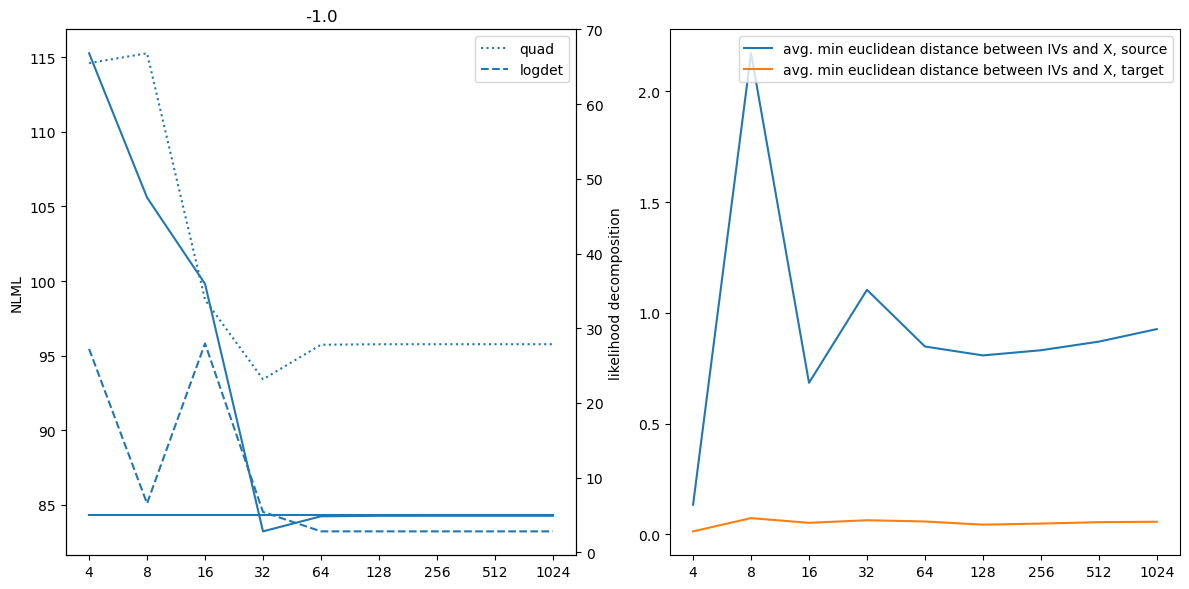

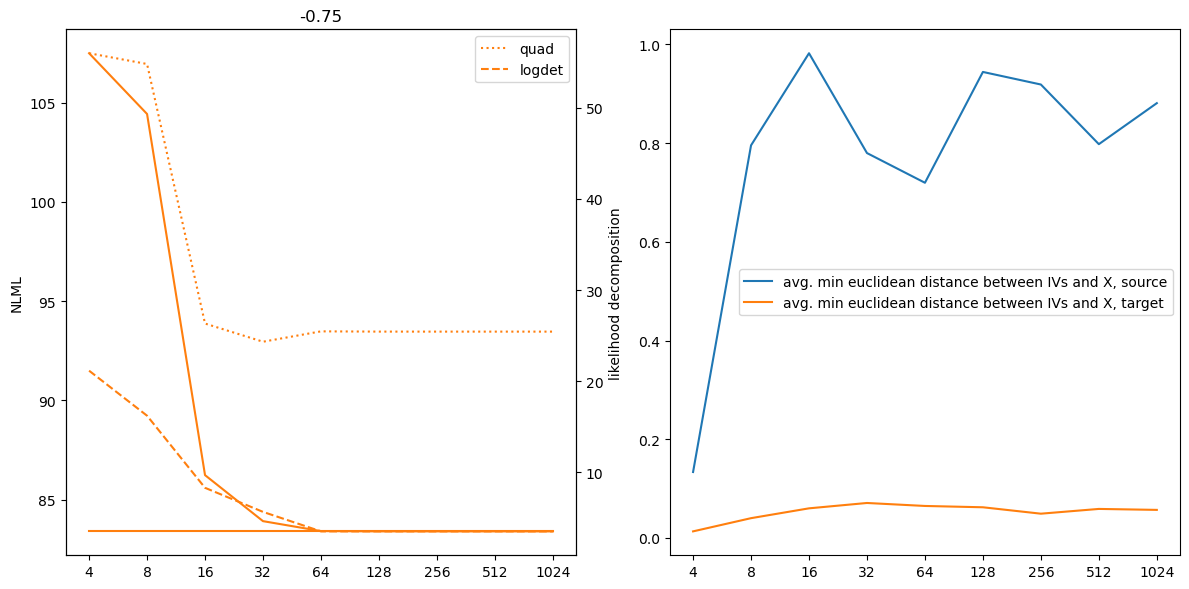

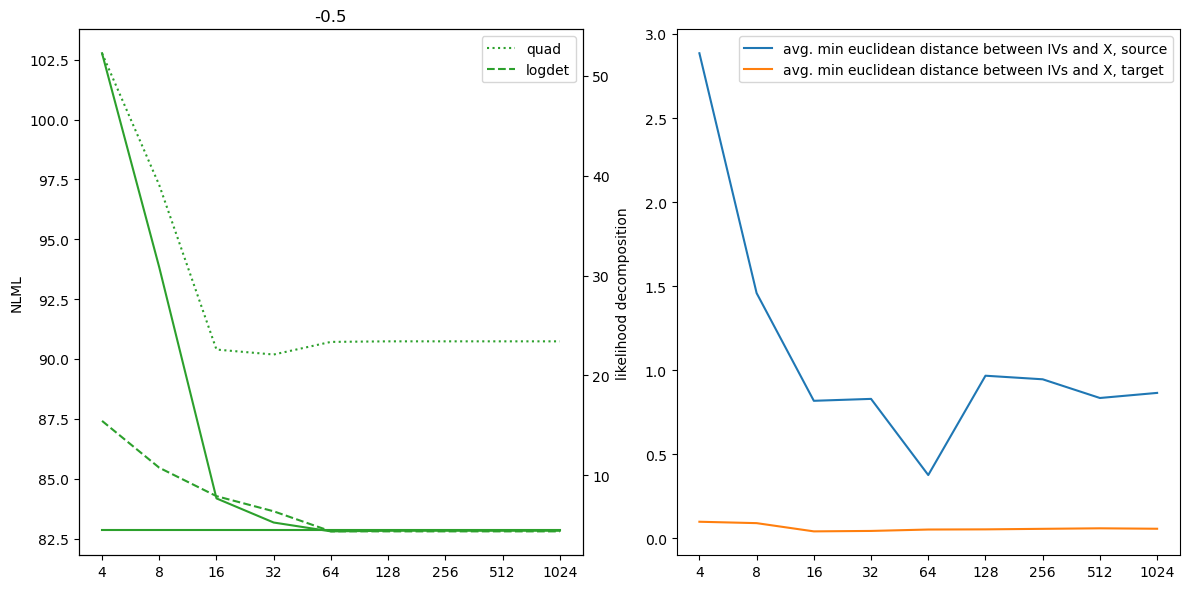

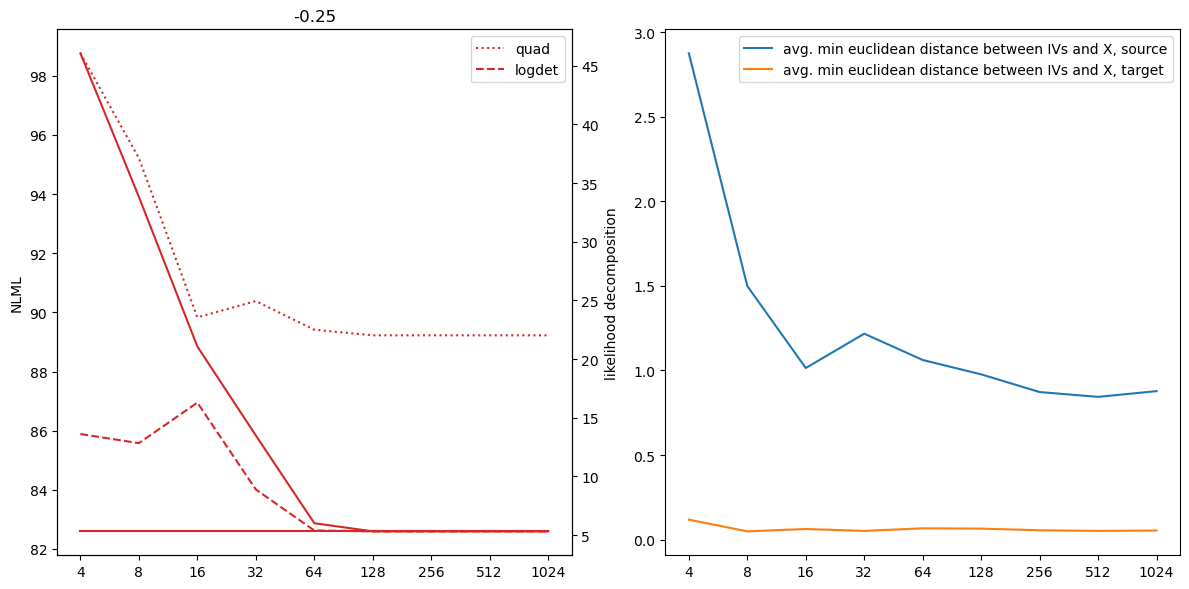

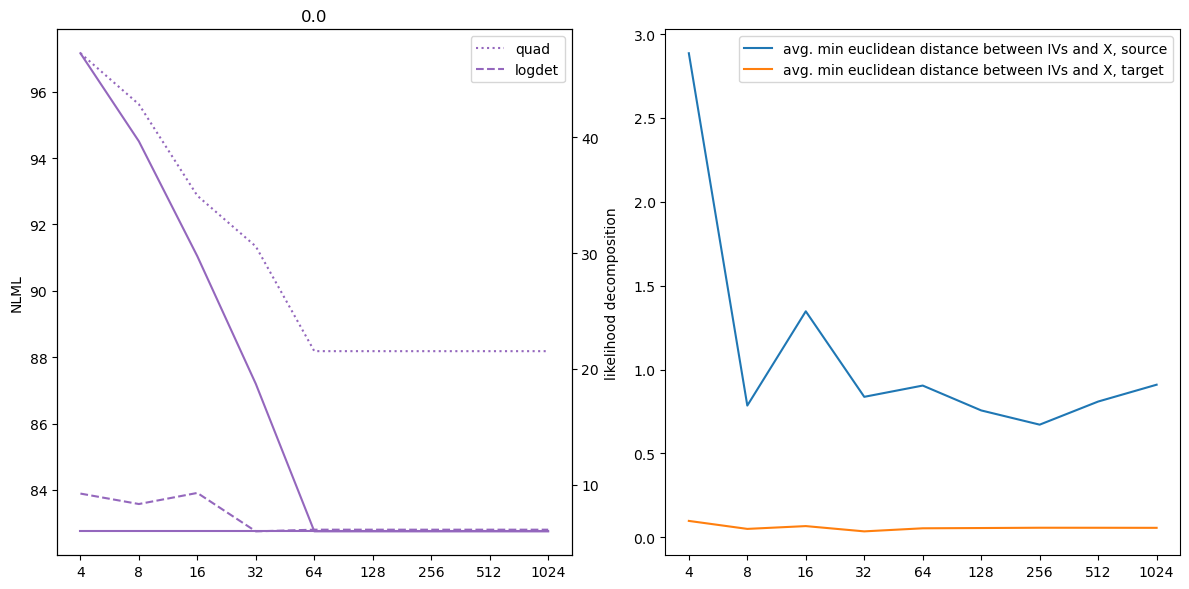

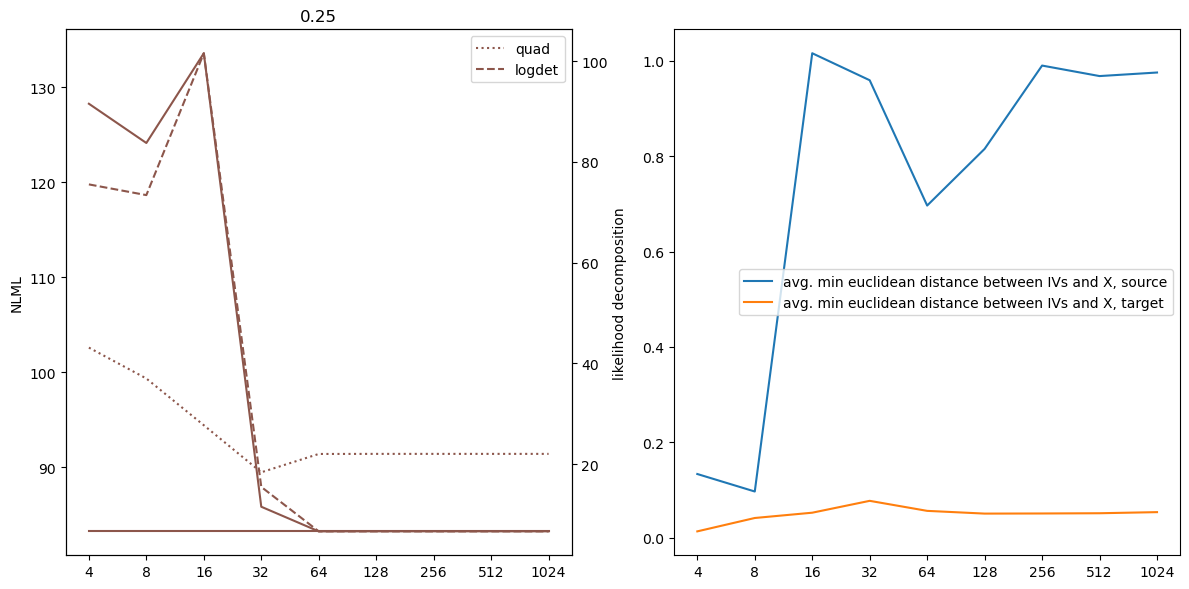

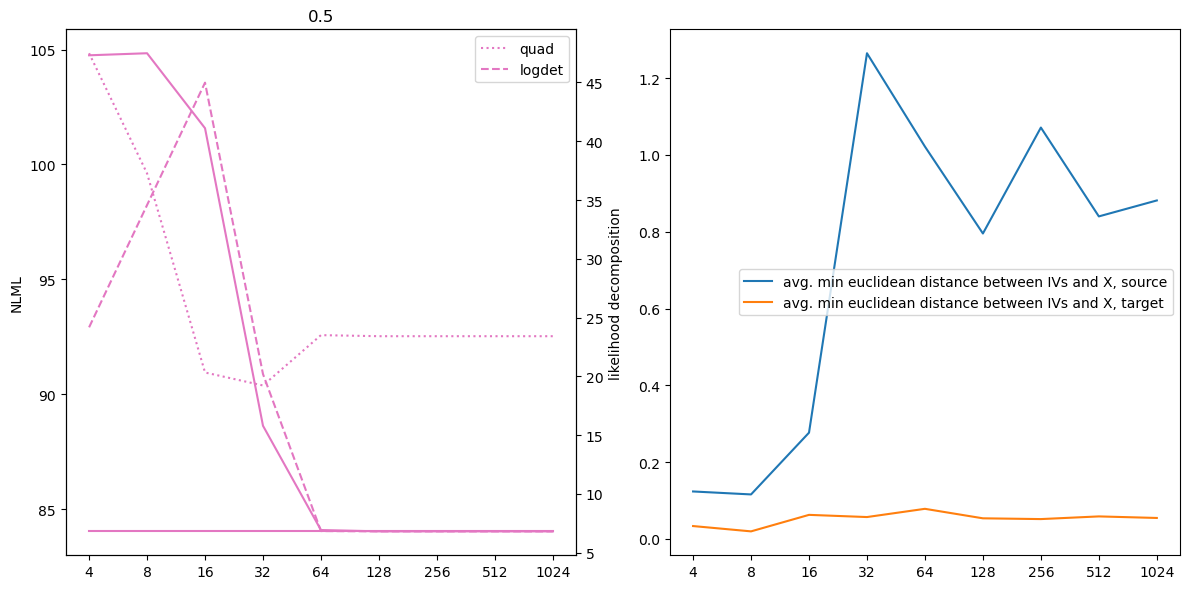

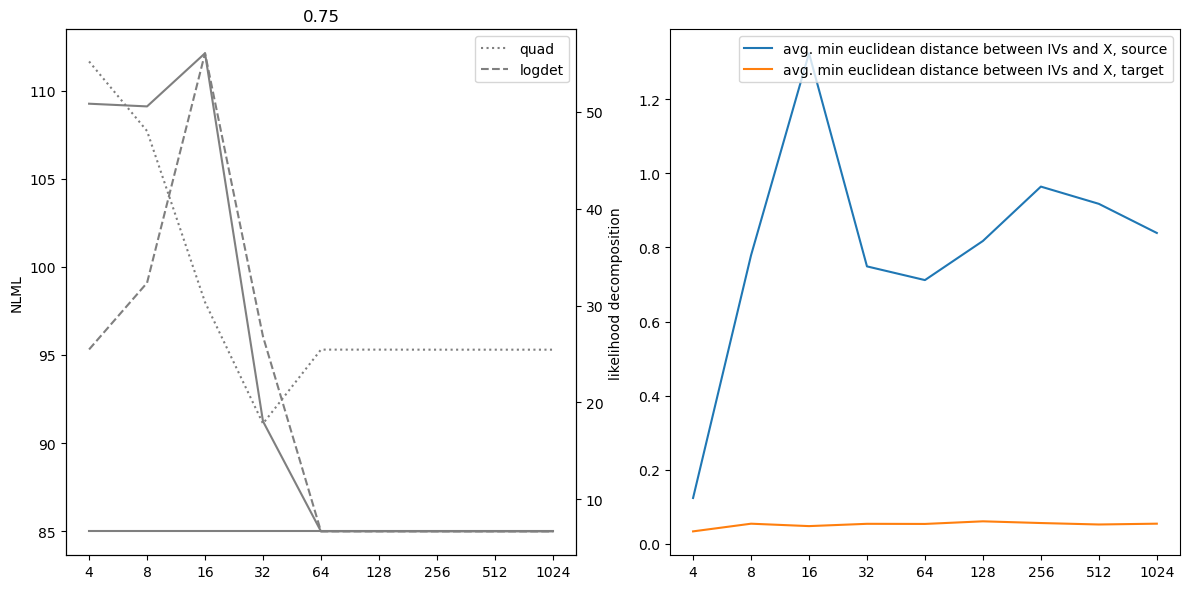

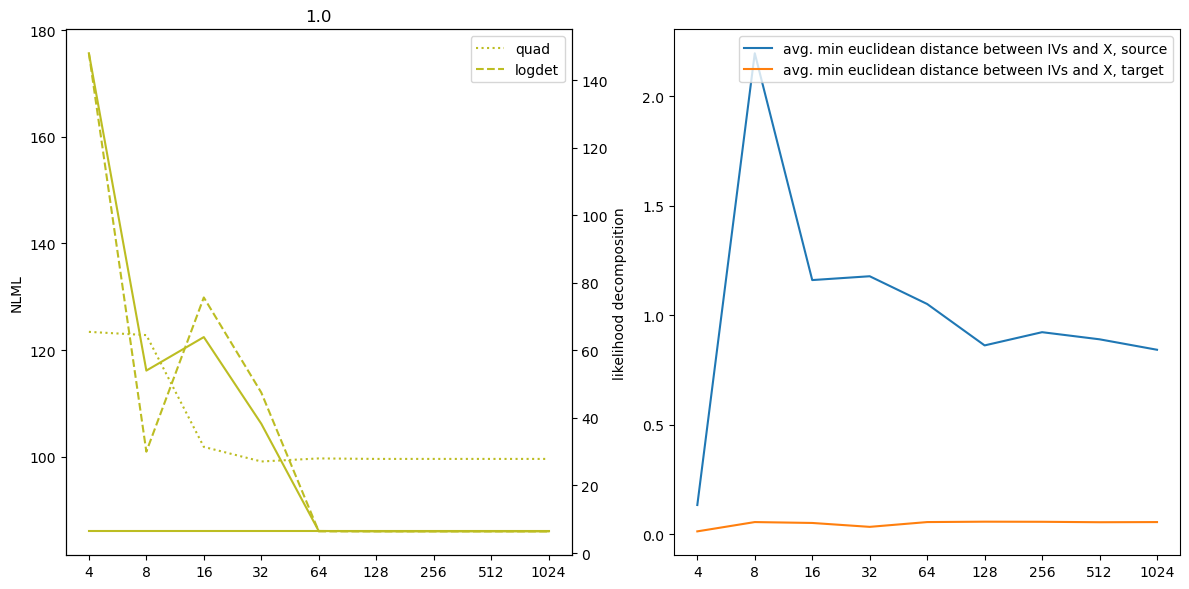

In [5]:
import matplotlib.colors as mcolors
colorlist = list(mcolors.TABLEAU_COLORS.values())
for j, l in enumerate(superlmls):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    components = ax[0].twinx()
    ax[0].plot(exponents, -l[:,0], color=colorlist[j], label=cross_cov[j])
    components.plot(exponents, l[:,1], color=colorlist[j], linestyle=":", label="quad")
    components.plot(exponents, l[:,2], color=colorlist[j], linestyle="--", label="logdet")
    ax[0].plot(exponents, -l[:,3], color=colorlist[j])
    plt.xticks(exponents, 2 ** exponents)
    plt.xlabel("Number of inducing points")
    ax[0].set_ylabel("NLML")
    components.set_ylabel("likelihood decomposition")
    ax[1].plot(exponents, l[:,-1], label="avg. min euclidean distance between IVs and X, source")
    ax[1].plot(exponents, l[:,-2], label="avg. min euclidean distance between IVs and X, target")
    ax[1].set_xticks(exponents, 2 ** exponents)
    ax[1].legend()
    plt.title(f"{cross_cov[j]}")
    plt.tight_layout()
    plt.legend()
    plt.show()

In [6]:
exponents = np.arange(2, 11)
supernoises = []
output_dim = 2  # Number of outputs
rank = 1  # Rank of W
cross_cov = np.arange(-1, 1.25, 0.25)
for i in cross_cov:
    noises = []
    for exponent in exponents:
        print(2 ** exponent)
        k = gpf.kernels.RBF(lengthscales=1)
        coreg = gpf.kernels.Coregion(
            output_dim=output_dim, rank=rank, active_dims=[1]
        )
        coreg.W = np.array([1., i]).reshape(-1, 1)
        kern = k * coreg
        m2 = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
        k = gpf.kernels.RBF(lengthscales=1)

        # Base kernel
        coreg = gpf.kernels.Coregion(
            output_dim=output_dim, rank=rank, active_dims=[1]
        )
        coreg.W = np.array([1., i]).reshape(-1, 1)

        # Coregion kernel
        ivs = np.linspace(0, max(X[:,0]), 2 ** exponent).reshape(-1, 1)
        iv_ind = np.concatenate((np.zeros((int(len(ivs)/2),1)), np.ones((int(len(ivs)/2),1))))
        shuffle = np.random.permutation(np.arange(len(ivs)))
        iv_ind = iv_ind[shuffle]
        ivs = np.hstack((ivs, iv_ind))
        kern = k * coreg
        m = SparseCMOGP((X, y), exact_target=False, kernel=kern, inducing_variable=ivs, jitter=1e-5, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
        optimize(m)
        optimize(m2)
        noise_sparse_source = m.likelihood.source.variance.numpy()
        noise_sparse_target = m.likelihood.target.variance.numpy()
        noise_full_source = m2.likelihood.source.variance.numpy()
        noise_full_target = m2.likelihood.target.variance.numpy()
        noises.append([noise_sparse_source, noise_sparse_target, noise_full_source, noise_full_target])
    print(noises)
    supernoises.append(noises)
supernoises = np.array(supernoises)

4
8
16
32
64
128
256
512
1024
[[array(0.06743373), array(0.00515132), array(1.e-06), array(0.00993736)], [array(1.1413174), array(0.0017759), array(1.e-06), array(0.00993736)], [array(0.15251513), array(1.99695799e-05), array(1.e-06), array(0.00993736)], [array(0.21346301), array(1.21494786e-05), array(1.e-06), array(0.00993736)], [array(2.24076596e-06), array(0.00629933), array(1.e-06), array(0.00993736)], [array(1.00000716e-06), array(0.00601427), array(1.e-06), array(0.00993736)], [array(1.00000161e-06), array(0.00619997), array(1.e-06), array(0.00993736)], [array(1.01912797e-06), array(0.00620674), array(1.e-06), array(0.00993736)], [array(1.00000011e-06), array(0.00624416), array(1.e-06), array(0.00993736)]]
4
8
16
32
64
128
256
512
1024
[[array(0.147254), array(0.00580043), array(0.0107238), array(0.00847916)], [array(0.70128773), array(1.00000001e-06), array(0.0107238), array(0.00847916)], [array(2.29996761e-06), array(0.00409326), array(0.0107238), array(0.00847916)], [array(1.